# 🎛️ Topic 04 — Hyperparameter Optimization & Experiment Tracking

Welcome! In this notebook, we are going to learn how to automatically find the best settings for our machine learning models using **Optuna**. We will also learn how to keep a neat and organized journal of all our experiments using **MLflow**.

Let's get started!

## 🧠 1. Hyperparameters vs. Model Parameters

Before we write code, let's understand the difference:
- **Model Parameters:** Things the model learns on its own from the data (like the slope of a line in regression).
- **Hyperparameters:** Settings *you* control before training starts (like how deep a decision tree is allowed to grow).

If we pick bad hyperparameters, our model will perform poorly. Let's create some data to demonstrate this.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for our charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Generate a synthetic dataset (like customer churn or fraud detection)
X, y = make_classification(n_samples=2000, n_features=20, n_informative=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Test data size: {X_test.shape}")

Training data size: (1600, 20)
Test data size: (400, 20)


## 🔍 2. The Problem with Guessing (Manual Tuning)

Let's train a model with some random settings (hyperparameters) and see how it does.

In [2]:
# We guess that n_estimators=10 and max_depth=2 are good settings
model_guess = RandomForestClassifier(n_estimators=10, max_depth=2, random_state=42)
model_guess.fit(X_train, y_train)

# Check performance
preds = model_guess.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, preds)
print(f"AUC Score with guessed parameters: {auc_score:.4f}")

AUC Score with guessed parameters: 0.8478


Can we do better? Instead of guessing, we can use a **Search Strategy**. The old way was **Grid Search** (checking every single combination). 

Let's visualize why Grid Search is slow compared to Random Search and Bayesian Optimization.

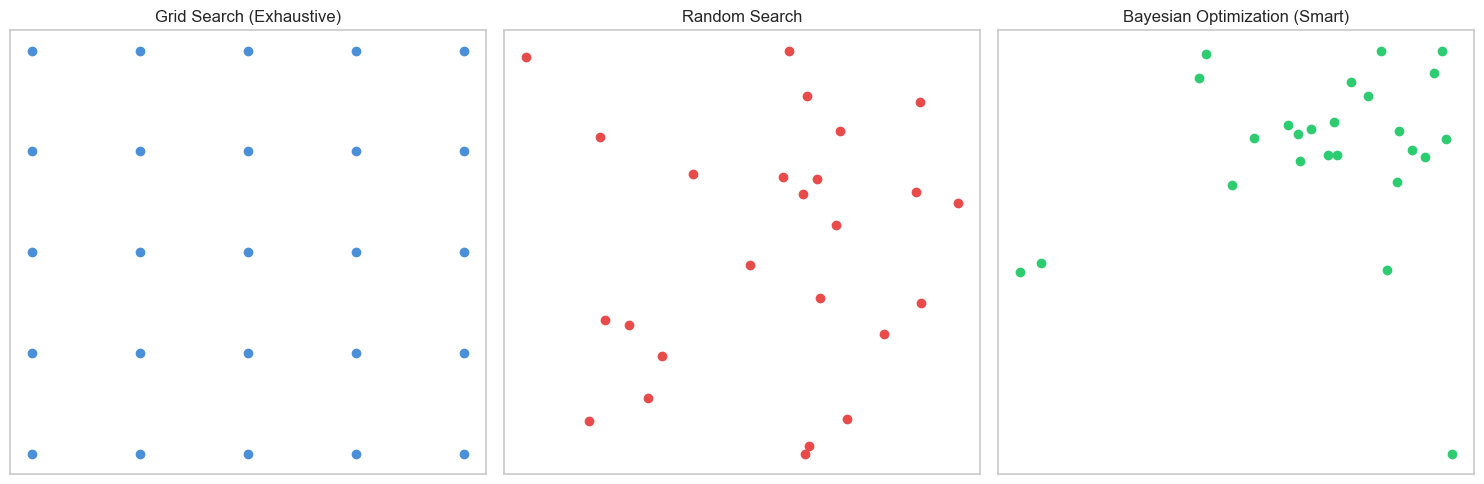

In [3]:
# EXPLAIN: Generating a 2D scatter comparison of search strategies
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Mock data for Grid
grid_x, grid_y = np.meshgrid(np.linspace(0, 10, 5), np.linspace(0, 10, 5))
axs[0].scatter(grid_x, grid_y, c='#4A90D9')
axs[0].set_title('Grid Search (Exhaustive)')

# Mock data for Random
axs[1].scatter(np.random.uniform(0, 10, 25), np.random.uniform(0, 10, 25), c='#E94B4B')
axs[1].set_title('Random Search')

# Mock data for Bayesian (focused in one area)
bayes_x = np.random.normal(7, 1, 20).tolist() + np.random.uniform(0, 10, 5).tolist()
bayes_y = np.random.normal(8, 1, 20).tolist() + np.random.uniform(0, 10, 5).tolist()
axs[2].scatter(bayes_x, bayes_y, c='#2ECC71')
axs[2].set_title('Bayesian Optimization (Smart)')

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 🎯 3. Enter Optuna (Bayesian Optimization)

Optuna is a brilliant library that learns from its mistakes. It will try a setting, see how the model performs, and use that information to pick better settings for the next try.

### 🏋️ Activity 1: Run Optuna on Random Forest
Let's define an `objective` function. Optuna will call this function repeatedly, each time passing a `trial` object that suggests different hyperparameter values.

In [4]:
# EXPLAIN: Install optuna and mlflow if you haven't already
# !pip install optuna mlflow

import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    
    # 2. Create the model with these suggested values
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    
    # 3. Evaluate the model using Cross Validation (very important: NEVER tune on the test set!)
    # We return the mean AUC score across 3 folds
    score = cross_val_score(clf, X_train, y_train, cv=3, scoring='roc_auc').mean()
    return score

# Create a study object and optimize!
study = optuna.create_study(direction='maximize') # We want to MAXIMIZE the AUC score
study.optimize(objective, n_trials=20) # Try 20 times (increase this in real projects)

print("\n🎉 Optimization Finished!")
print(f"Best Score: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-09-04 00:25:37,036] A new study created in memory with name: no-name-9c4ea4fb-6237-4b02-8a94-382157993c4f
[I 2026-09-04 00:25:38,352] Trial 0 finished with value: 0.9115417842253236 and parameters: {'n_estimators': 235, 'max_depth': 3, 'min_samples_split': 13}. Best is trial 0 with value: 0.9115417842253236.
[I 2026-09-04 00:25:39,992] Trial 1 finished with value: 0.9647582780261402 and parameters: {'n_estimators': 170, 'max_depth': 19, 'min_samples_split': 8}. Best is trial 1 with value: 0.9647582780261402.
[I 2026-09-04 00:25:41,467] Trial 2 finished with value: 0.9644878900388903 and parameters: {'n_estimators': 168, 'max_depth': 9, 'min_samples_split': 2}. Best is trial 1 with value: 0.9647582780261402.
[I 2026-09-04 00:25:43,445] Trial 3 finished with value: 0.9645159975926294 and parameters: {'n_estimators': 188, 'max_depth': 13, 'min_samples_split': 11}. Best is trial 1 with value: 0.9647582780261402.
[I 2026-09-04 00:25:46,160] Trial 4 finished with value: 0.96660509723


🎉 Optimization Finished!
Best Score: 0.9674
Best Parameters: {'n_estimators': 222, 'max_depth': 20, 'min_samples_split': 3}


Wow! Optuna found settings that give us a much better score than our manual guess. 

Let's visualize the journey Optuna took.

In [ ]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

# 1. Optimization History: See how the score improved over time
fig1 = plot_optimization_history(study)
fig1.show()

In [ ]:
# 2. Hyperparameter Importance: Which setting mattered the most?
fig2 = plot_param_importances(study)
fig2.show()

In [ ]:
# 3. Parallel Coordinates: See the paths that lead to the best scores (yellow/bright lines)
fig3 = plot_parallel_coordinate(study)
fig3.show()

## 📓 4. MLflow: Your ML Journal

Now that we found the best parameters, how do we save them? How do we prove to our boss next week that we ran this experiment? 

We use **MLflow**. 

### 🏋️ Activity 2: Log to MLflow
We will create a new run, log our best parameters, our final metrics, and even the model itself!

In [ ]:
import mlflow
import mlflow.sklearn

# Set an experiment name so things are organized
mlflow.set_experiment("Bootcamp_Optuna_Experiments")

# Start a new "Run"
with mlflow.start_run(run_name="Best_RF_Model"):
    
    # 1. Log the best parameters we found from Optuna
    mlflow.log_params(study.best_params)
    
    # 2. Train the final model on the FULL training set using the best params
    best_model = RandomForestClassifier(**study.best_params, random_state=42)
    best_model.fit(X_train, y_train)
    
    # 3. Evaluate on the Test Set
    test_preds = best_model.predict_proba(X_test)[:, 1]
    final_test_auc = roc_auc_score(y_test, test_preds)
    
    # 4. Log the metric
    mlflow.log_metric("test_auc", final_test_auc)
    print(f"Final Test AUC logged: {final_test_auc:.4f}")
    
    # 5. Log the actual model (this saves the .pkl file automatically!)
    mlflow.sklearn.log_model(best_model, "random_forest_model")
    
    print("✅ Experiment logged successfully to MLflow!")

## 🏆 What just happened?

Behind the scenes, MLflow created a folder called `mlruns/` and saved all our data there. 

To view the beautiful MLflow Dashboard, you would normally open your terminal and type:
`mlflow ui`

Then you can open your browser to `http://localhost:5000` and see all your experiments beautifully organized!

## 📝 Key Takeaways & Quiz

### Key Takeaways:
- **Don't guess:** Use Optuna to systematically search for hyperparameters.
- **Never tune on the test set:** We used `cross_val_score` on the training data to guide Optuna.
- **Track everything:** Use MLflow to save your parameters, metrics, and models. If it's not logged, it's lost!

### ❓ Quiz (Check your understanding)
1. If we are trying to find the best `learning_rate`, is that a Model Parameter or a Hyperparameter?
2. Why is Bayesian Optimization (Optuna) generally faster and better than Grid Search?
3. What command do you type in the terminal to view your MLflow dashboard?